# **EDA & Preprocessing**

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the Dataset

dataset_raw = pd.read_csv('online_shoppers_intention.csv')

dataset = dataset_raw.copy()
dataset.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Checking the data types

dataset.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [4]:
# Checking the dataset shape

dataset.shape

(12330, 18)

In [5]:
# Re-validating the dataset for missing values

dataset.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
# Checking is there any duplicated rows in the dataset

dataset.duplicated().sum()

np.int64(125)

In [7]:
# Checking the distribution of the target variable, the target of this dataset is 'Revenue'

dataset['Revenue'].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

In [8]:
# Due to duplpicated values in the dataset, we will drop the duplicated rows

dataset.drop_duplicates(inplace=True)

In [9]:
# New dataset shape after dropping duplicated rows

dataset.shape

(12205, 18)

# **EDA**

**Univariate**

In [10]:
# Numerical Features 

num_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
             'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

In [11]:
# Checking the skewness of the numerical features

dataset[num_cols].skew().sort_values(ascending=False)

Informational_Duration     7.540291
ProductRelated_Duration    7.253161
PageValues                 6.350983
Administrative_Duration    5.592152
ProductRelated             4.333419
Informational              4.014173
SpecialDay                 3.285902
BounceRates                3.162425
ExitRates                  2.234645
Administrative             1.947123
dtype: float64

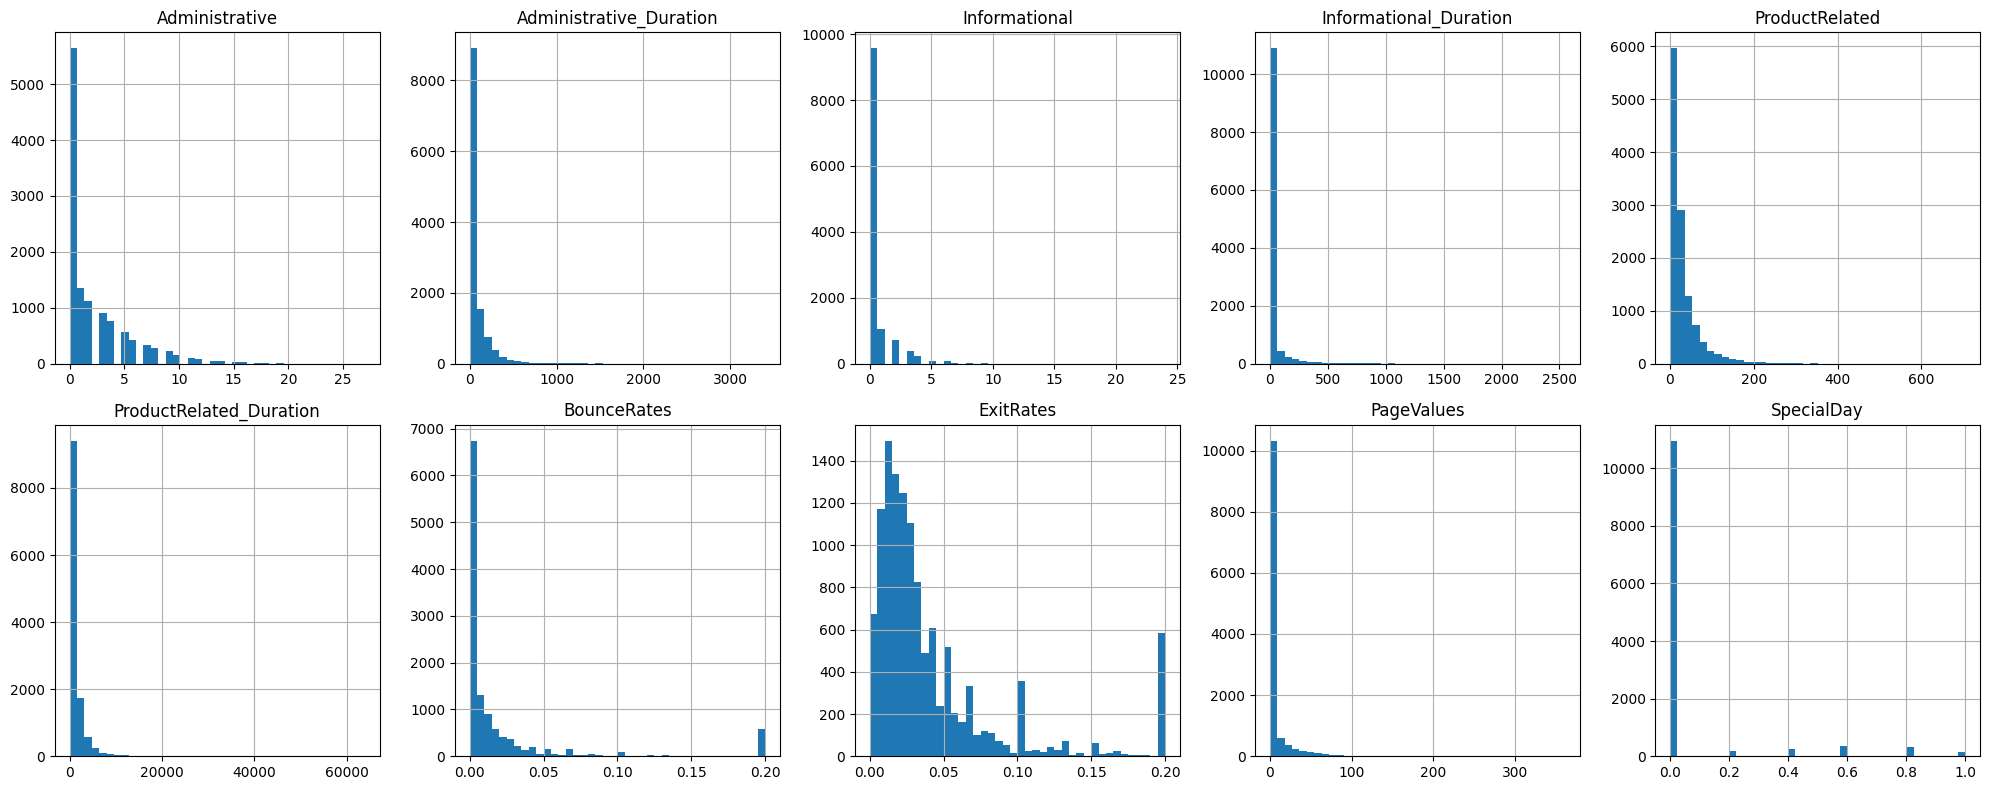

In [12]:
# Visualization  spot putliers and skewness of the numerical features

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(num_cols):
    dataset[col].hist(ax=axes[i//5, i%5], bins=40)
    axes[i//5, i%5].set_title(col)
plt.tight_layout()
plt.show()

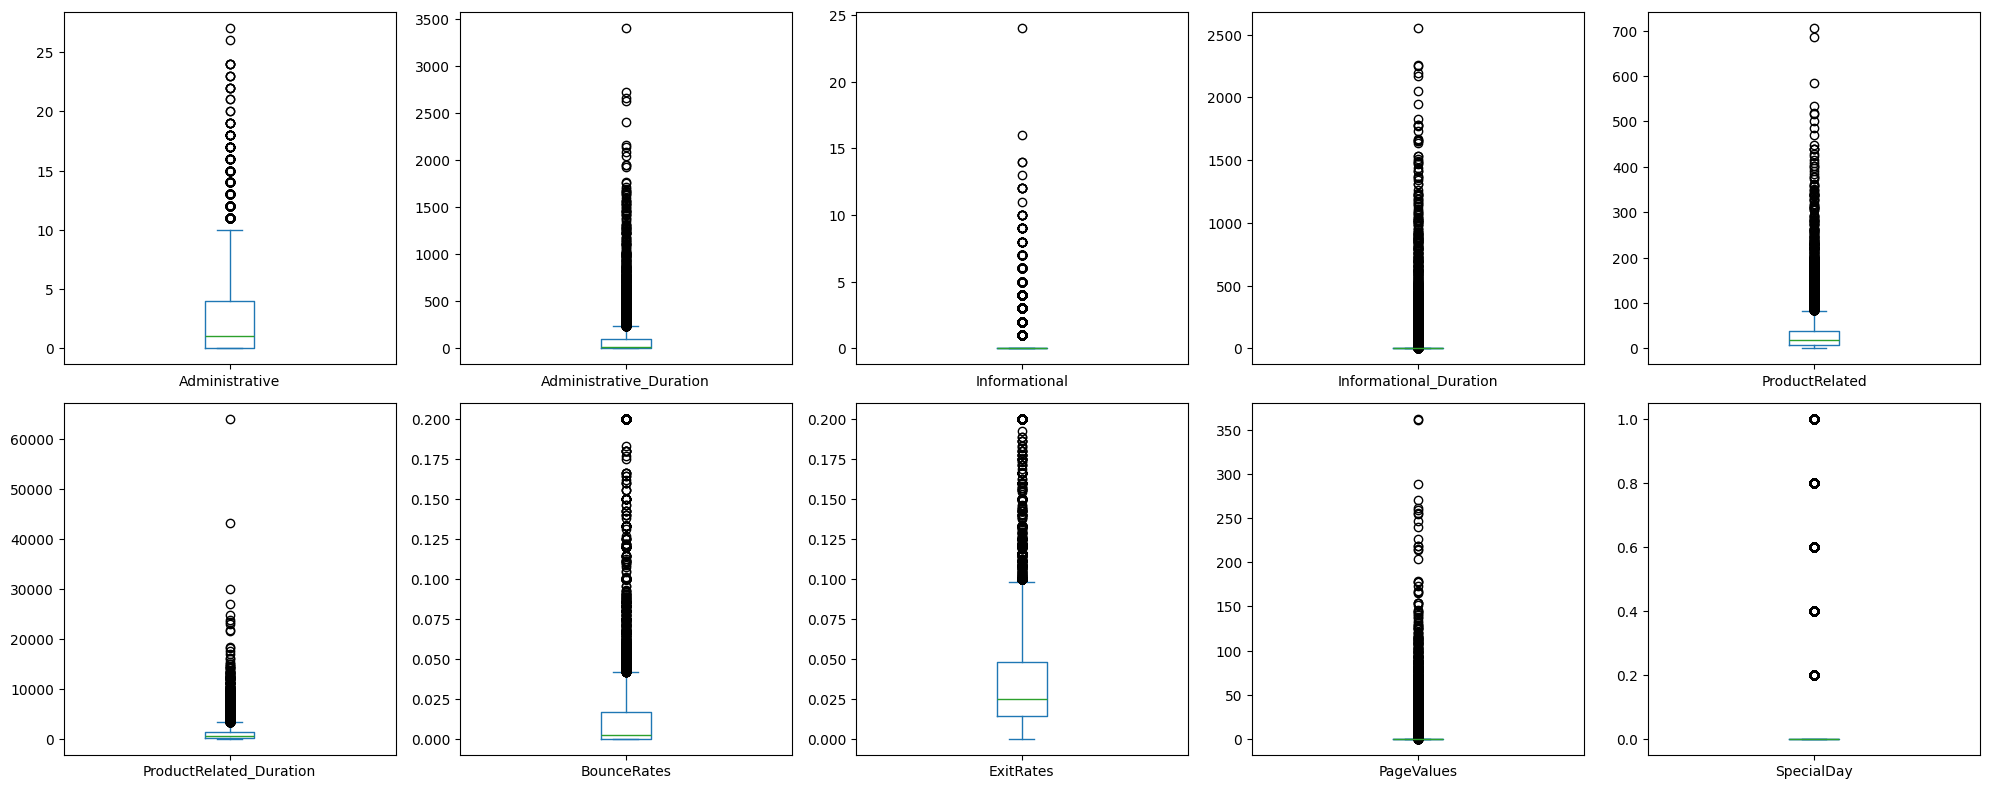

In [13]:
# Boxplots for outliers visibility

dataset[num_cols].plot(kind='box', subplots=True, layout=(2, 5), figsize=(20, 8), sharey=False)
plt.tight_layout()
plt.show()

In [14]:
# Categorical Features

cat_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType']

In [15]:
for col in cat_cols:
    print(dataset[col].value_counts(), '\n')

Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64 

OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64 

Browser
2     7883
1     2427
4      731
5      465
6      174
10     163
8      135
3      105
13      56
7       49
12      10
11       6
9        1
Name: count, dtype: int64 

Region
1    4714
3    2379
4    1171
2    1128
6     801
7     758
9     505
8     431
5     318
Name: count, dtype: int64 

TrafficType
2     3911
1     2388
3     2013
4     1066
13     728
10     450
6      443
8      343
5      260
11     247
20     193
9       41
7       40
15      37
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64 

VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64 



**Bivariate**
Feature vs Revenue

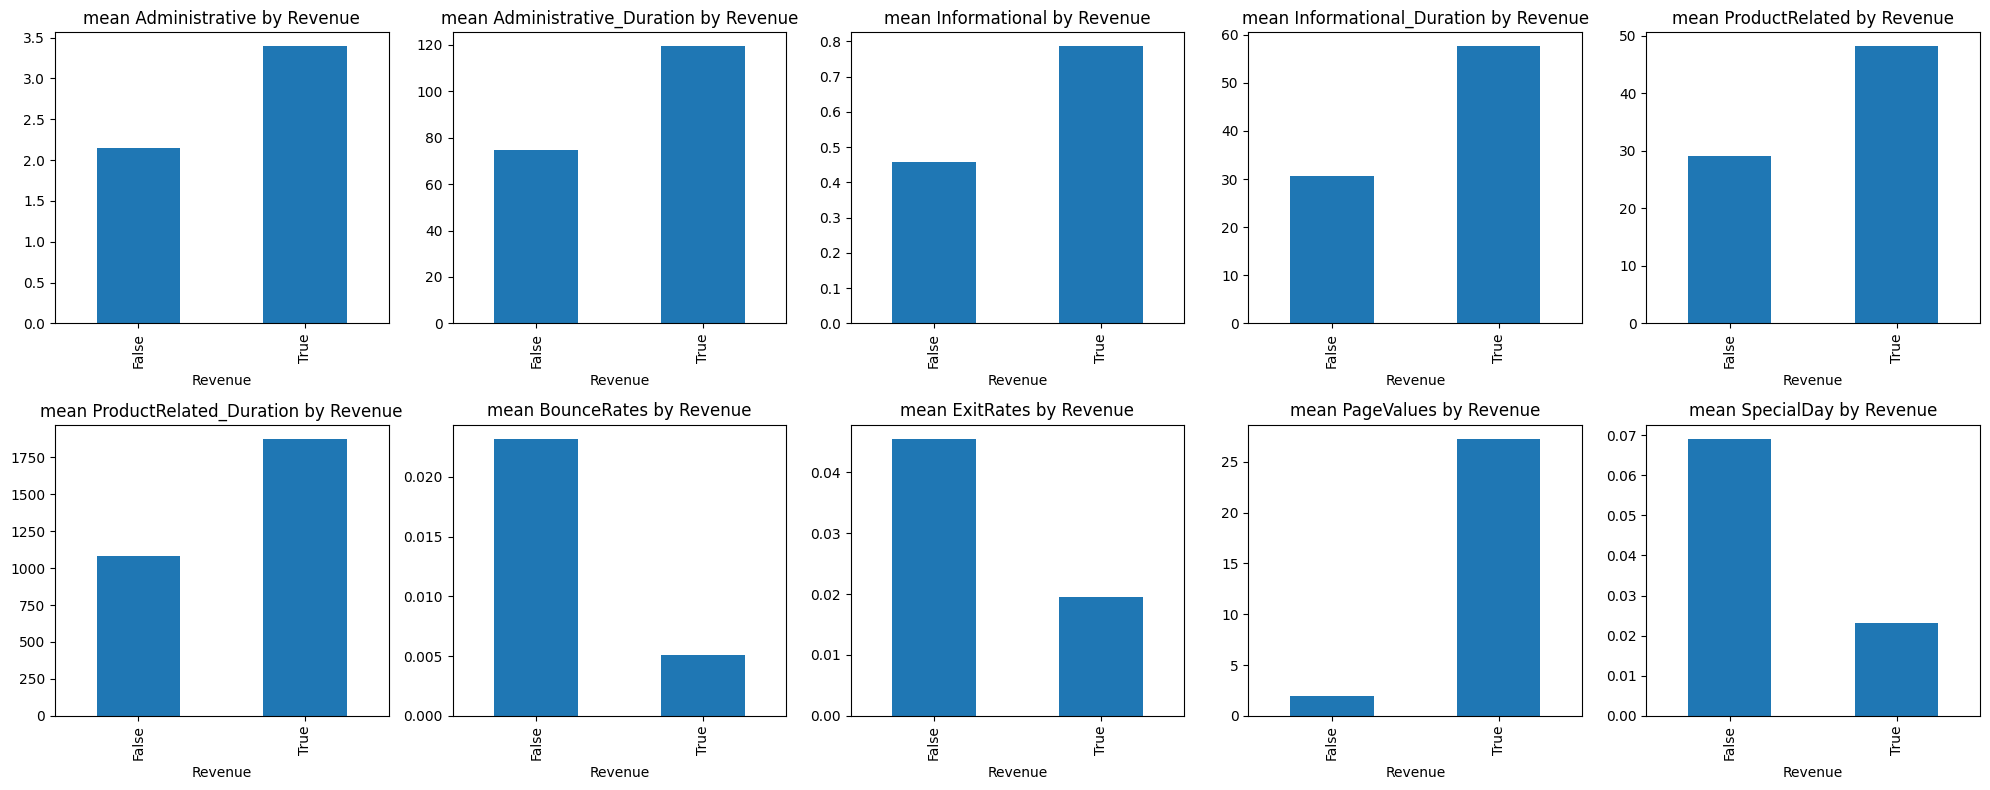

In [16]:
# Numercial Features vs Revenue

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(num_cols):
    dataset.groupby('Revenue')[col].mean().plot(kind='bar', ax=axes[i//5, i%5])
    axes[i//5, i%5].set_title(f'mean {col} by Revenue')
plt.tight_layout()
plt.show()


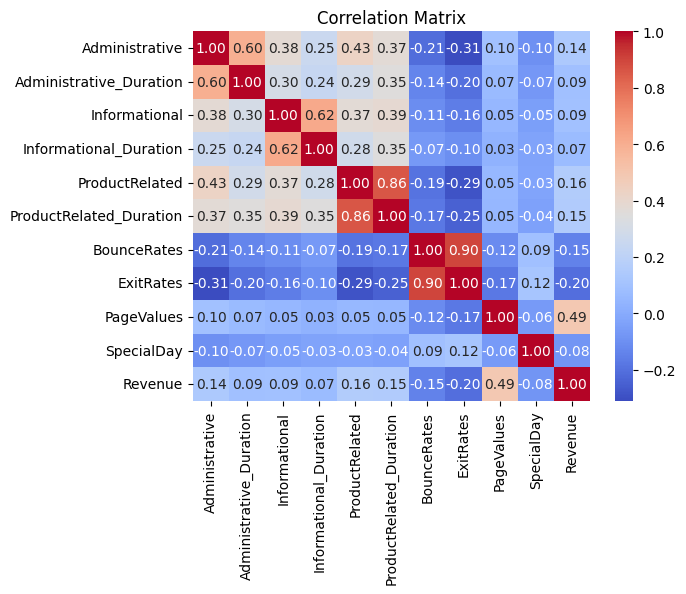

In [17]:
# Correlation Matrix

corr = dataset[num_cols + ['Revenue']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

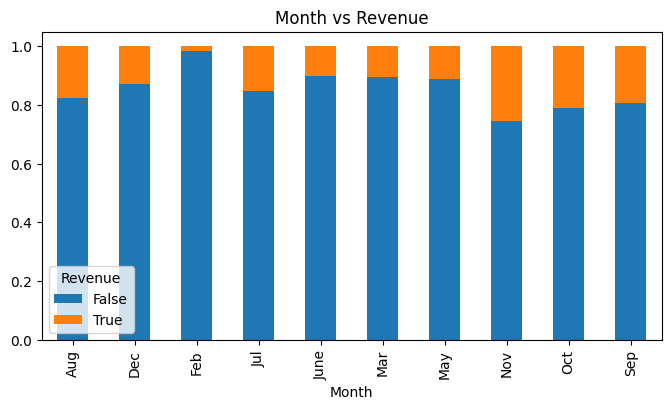

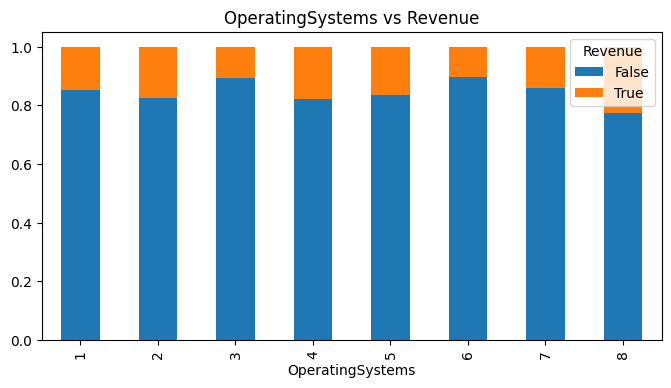

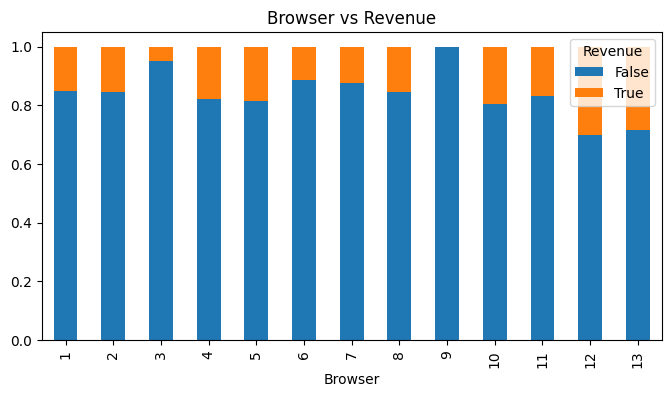

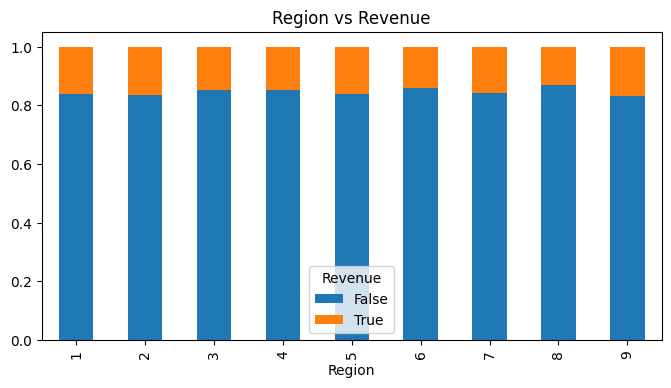

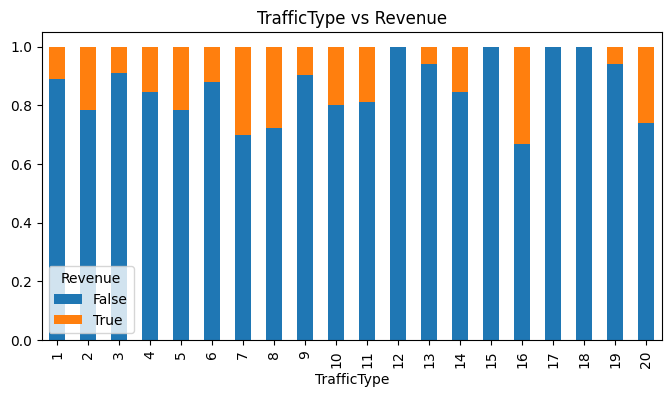

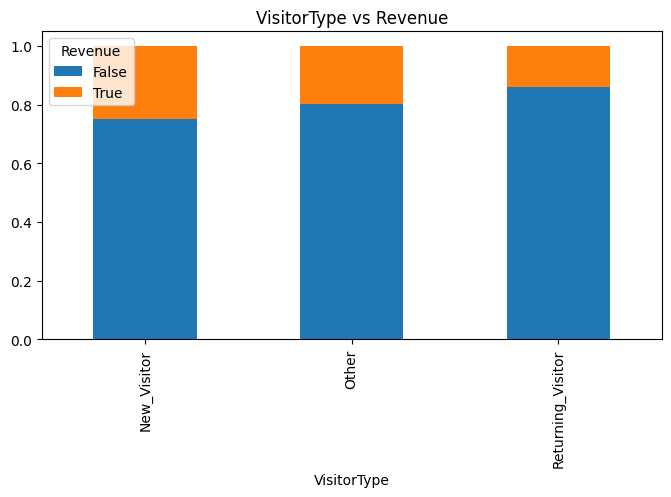

In [18]:
# Categorical features vs Revenue

for col in cat_cols:
    ct = pd.crosstab(dataset[col], dataset['Revenue'], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(8, 4))
    plt.title(f'{col} vs Revenue')
    plt.show()

# **Preprocessing**

**Encoding Boolean Columns**

In [21]:
dataset['Revenue'] = dataset['Revenue'].astype(int)
dataset['Weekend'] = dataset['Weekend'].astype(int)

In [22]:
print(dataset[['Revenue', 'Weekend']].dtypes)
print(dataset[['Revenue', 'Weekend']].head())

Revenue    int64
Weekend    int64
dtype: object
   Revenue  Weekend
0        0        0
1        0        0
2        0        0
3        0        0
4        0        1


**Encode Categorical Feature**


In [24]:
from sklearn.preprocessing import LabelEncoder

# Visitor Type
le = LabelEncoder()
dataset['VisitorType'] = le.fit_transform(dataset['VisitorType'])
print(dataset['VisitorType'].unique())

[2 0 1]


In [26]:
# Month
dataset = pd.get_dummies(dataset, columns=['Month'], drop_first=True)
print("Shape after encoding Month:", dataset.shape)
dataset.head()

Shape after encoding Month: (12205, 26)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,False,True,False,False,False,False,False,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,False,True,False,False,False,False,False,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,False,True,False,False,False,False,False,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,False,True,False,False,False,False,False,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,False,True,False,False,False,False,False,False,False


** Cap outliers at 99 percentile**

In [27]:
skewed_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration','ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

for col in skewed_cols:
    cap = dataset[col].quantile(0.99)
    dataset[col] = dataset[col].clip(upper=cap)

print("Outliers Capped")
print(dataset[skewed_cols].describe())

Outliers Capped
       Administrative  Administrative_Duration  Informational  \
count    12205.000000             12205.000000   12205.000000   
mean         2.309218                77.021957       0.490455   
std          3.199232               142.728817       1.154280   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 9.000000       0.000000   
75%          4.000000                94.700000       0.000000   
max         14.000000               838.704889       6.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12205.000000    12205.000000             12205.000000   
mean                30.696256       31.127735              1164.588940   
std                105.268590       38.331027              1555.729802   
min                  0.000000        0.000000                 0.000000   
25%                  0.00000

**Skewness Fix**

In [28]:
# To the skewness of the dataset after capping the outliers we need to fix 

for col in skewed_cols:
    dataset[col] = np.log1p(dataset[col])

In [29]:
print(dataset[skewed_cols].skew().sort_values(ascending=False))

BounceRates                3.078066
ExitRates                  2.130249
Informational              1.928873
Informational_Duration     1.876796
PageValues                 1.755429
Administrative             0.534436
Administrative_Duration    0.224690
ProductRelated            -0.085971
ProductRelated_Duration   -1.449622
dtype: float64


**Skewness Fixed Part 2**

- Although we already use log1p to fix the skewness, but several values still exceed 1.0
- Here we will use Yeo-Johnson technique, to reduce the skew value

In [31]:
from sklearn.preprocessing import PowerTransformer

yeo_cols = ['BounceRates', 'ExitRates', 'Informational', 'Informational_Duration', 'PageValues', 'ProductRelated_Duration']

pt = PowerTransformer(method='yeo-johnson')
dataset[yeo_cols] = pt.fit_transform(dataset[yeo_cols])

print(dataset[skewed_cols].skew().sort_values(ascending=False))

Informational_Duration     1.524452
Informational              1.385165
PageValues                 1.340796
BounceRates                0.975771
Administrative             0.534436
ExitRates                  0.381381
Administrative_Duration    0.224690
ProductRelated            -0.085971
ProductRelated_Duration   -0.338123
dtype: float64


**Split the dataset into Test and Train**

In [33]:
from sklearn.model_selection import train_test_split

X = dataset.drop('Revenue', axis=1)
y = dataset['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))

Training set shape: (9764, 25)
Test set shape: (2441, 25)
y_train distribution:
 Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64


**Scaling**

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(9764, 25) (2441, 25)


**Handling Class Imbalance using SMOTE**

In [36]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print("X_train_res shape:", X_train_res.shape)
print("Class distribution:\n", pd.Series(y_train_res).value_counts())
print("Class distribution:\n", pd.Series(y_train_res).value_counts())

After SMOTE:
X_train_res shape: (16476, 25)
Class distribution:
 Revenue
1    8238
0    8238
Name: count, dtype: int64
Class distribution:
 Revenue
1    8238
0    8238
Name: count, dtype: int64


**Final Validation**

In [37]:
# No nulls anywhere
print("Nulls in train:", pd.DataFrame(X_train_res).isnull().sum().sum())
print("Nulls in test:", pd.DataFrame(X_test_scaled).isnull().sum().sum())

# Confirm shapes make sense
print("Final train shape:", X_train_res.shape)
print("Final test shape:", X_test_scaled.shape)
print("y_test distribution:\n", y_test.value_counts(normalize=True))

Nulls in train: 0
Nulls in test: 0
Final train shape: (16476, 25)
Final test shape: (2441, 25)
y_test distribution:
 Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64
